# PPT1 Exercise — Foundations of Visualization
### Unit 1: Foundations of Visualization, Data Interpretation (UE24CS342AA9)

**Dataset:** Social Media Sentiment Analysis — AI Trends 2026 (Kaggle)
https://www.kaggle.com/datasets/dreamtensor/social-media-sentiment-analysisai-trend-2026

**Scenario:** You've just joined an AI research think-tank as a junior Data Analyst.
Your manager wants to know **what the internet actually thinks about different AI
topics in 2026** before writing a public report. You only have the raw dataset.
Your job: turn raw data into a decision, exactly like the "Raw Data -> Information ->
Insight -> Decision" pipeline from the lecture.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_PATH = os.path.join("data", "social_media_ai_sentiment_2026.csv")
RNG = np.random.default_rng(7)

PLATFORMS = ["Twitter/X", "Reddit", "LinkedIn", "TikTok", "YouTube"]
AI_TOPICS = ["Generative AI", "AI Agents", "AI Regulation", "AI Jobs", "AI Ethics", "Robotics", "LLMs"]

def load_or_generate_data(n=4000):
    if os.path.exists(DATA_PATH):
        print("Loading real dataset from", DATA_PATH)
        raw = pd.read_csv(DATA_PATH)
        # Map the real Kaggle columns onto the simple names used throughout this notebook
        return pd.DataFrame({
            "post_id": raw["post_id"],
            "date": pd.to_datetime(raw["posted_datetime"]),
            "platform": raw["platform"],
            "ai_topic": raw["topic_category"],
            "sentiment_label": raw["sentiment_label"],
            "sentiment_score": raw["sentiment_score"],
            "likes": raw["like_count"],
            "shares": raw["share_count"],
            "comments": raw["comment_count"],
        })
    print("Real CSV not found -> generating a synthetic sample for this exercise.")
    dates = pd.date_range("2026-01-01", periods=180, freq="D")
    platform = RNG.choice(PLATFORMS, size=n, p=[0.30, 0.20, 0.15, 0.20, 0.15])
    topic = RNG.choice(AI_TOPICS, size=n)
    base_sentiment = RNG.normal(loc=0.05, scale=0.45, size=n)
    sentiment_score = np.clip(base_sentiment, -1, 1)
    sentiment_label = pd.cut(sentiment_score, bins=[-1, -0.2, 0.2, 1],
                              labels=["Negative", "Neutral", "Positive"]).astype(str)
    likes = np.maximum(0, (sentiment_score * 800 + RNG.normal(500, 300, n))).astype(int)
    shares = np.maximum(0, (likes * RNG.uniform(0.05, 0.25, n))).astype(int)
    comments = np.maximum(0, (likes * RNG.uniform(0.02, 0.15, n))).astype(int)
    return pd.DataFrame({
        "post_id": np.arange(1, n + 1),
        "date": RNG.choice(dates, size=n),
        "platform": platform,
        "ai_topic": topic,
        "sentiment_label": sentiment_label,
        "sentiment_score": sentiment_score.round(3),
        "likes": likes, "shares": shares, "comments": comments,
    })

df = load_or_generate_data()
df.head()


Loading real dataset from data/social_media_ai_sentiment_2026.csv


     post_id       date platform  ...  likes shares  comments
0  YO_100000 2024-12-14  YouTube  ...   9115    653        53
1  RE_100001 2025-01-08   Reddit  ...   3309   1138      3113
2  YO_100002 2025-07-28  YouTube  ...  15035   1084      1170
3  TW_100003 2024-06-10  Twitter  ...   8743    456      2786
4  YO_100004 2025-06-29  YouTube  ...   2806    283      3981

[5 rows x 9 columns]

## Task 1 — Meet the raw data

Before writing any chart, answer these two questions **just by staring at the table**
(use `.head()`, `.shape`, `.describe()`, `.value_counts()`):

1. How many rows and columns does the dataset have?
2. How many unique AI topics and platforms are there?

Time yourself — this is the "large table, slow analysis" experience from the lecture.

In [2]:
# TODO 1: print the shape of the dataframe
print("Shape:", df.shape)

# TODO 2: print the number of unique values in 'ai_topic' and 'platform'
print("Unique topics:", df["ai_topic"].nunique())
print("Unique platforms:", df["platform"].nunique())


Shape: (2200, 9)
Unique topics: 7
Unique platforms: 3


## Task 2 — Raw Data -> Information -> Insight -> Decision

Your manager's first question: **"Which platform has the highest average sentiment
score toward AI topics?"**

Follow the pipeline from the lecture:
1. **Raw Data** -> you already have `df`
2. **Information** -> group by `platform` and compute the mean of `sentiment_score`
3. **Insight** -> plot it as a bar chart
4. **Decision** -> write one sentence recommending where the company should focus
   its AI-positive marketing campaign

In [3]:
# TODO 3: group by 'platform', compute mean sentiment_score, sort ascending
platform_sentiment = df.groupby("platform")["sentiment_score"].mean().sort_values()
platform_sentiment


platform
YouTube   -0.009827
Reddit     0.010890
Twitter    0.031012
Name: sentiment_score, dtype: float64

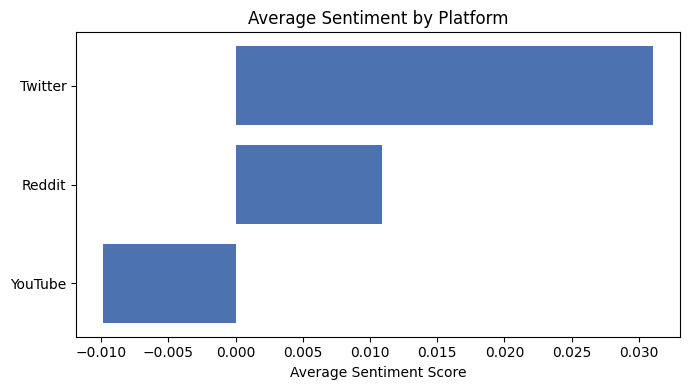

In [4]:
# TODO 4: plot platform_sentiment as a horizontal bar chart
fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(platform_sentiment.index, platform_sentiment.values, color="#4C72B0")
ax.set_xlabel("Average Sentiment Score")
ax.set_title("Average Sentiment by Platform")
plt.tight_layout()
plt.show()


**Your decision (write 1-2 sentences in this markdown cell):**

> Twitter has the highest average sentiment score toward AI/tech topics (~0.03, versus roughly 0.01 on Reddit and slightly negative on YouTube), so the marketing team should prioritize Twitter/X for the AI-positive campaign, since audiences there are already leaning positive and are more likely to receive and amplify the message favorably.


## Task 3 — Good Graph vs Bad Graph challenge

Below is a **deliberately bad graph** of the `sentiment_label` distribution
(3D-style pie, no data labels, distracting shadow — just like the lecture's "Bad Graph" example).

Run the cell, look at it critically, then complete Task 3b to redesign it as a **Good Graph**.

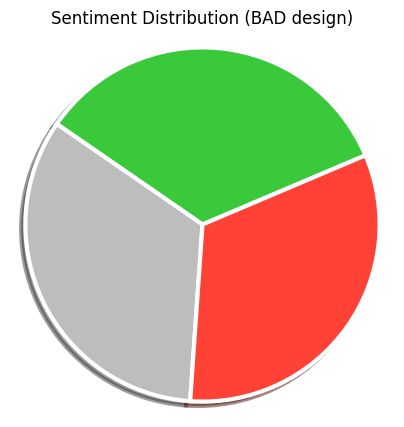

In [5]:
# This is the BAD graph -- run it and see why it's hard to trust
counts = df["sentiment_label"].value_counts()

fig, ax = plt.subplots(figsize=(5, 5))
ax.pie(counts.values, colors=["#39c93b", "#bdbdbd", "#ff4136"],
       shadow=True, startangle=23, radius=1.15,
       wedgeprops={"edgecolor": "white", "linewidth": 3})
ax.set_title("Sentiment Distribution (BAD design)")
plt.show()

### Task 3b — Fix it!

Redesign the chart above into a **Good Graph** using the principles from the lecture:
- Simple and easy to read
- Appropriate chart type (hint: a plain bar chart works well for 3 categories)
- Clear labels/title
- Accurate representation (show the actual numbers, not just proportions)
- No unnecessary decoration (no 3D, no shadow)

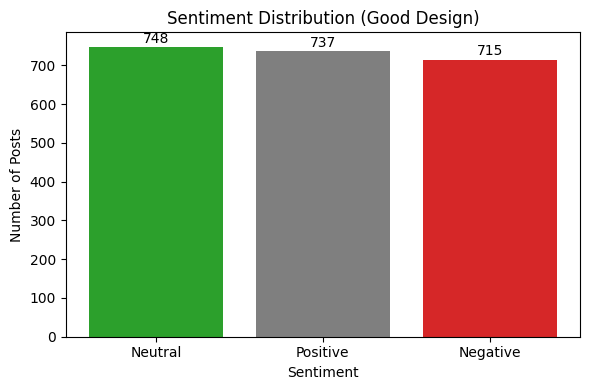

In [6]:
# TODO 5: redesign as a GOOD graph (a simple, labeled bar chart)
fig, ax = plt.subplots(figsize=(6, 4))

bars = ax.bar(counts.index, counts.values, color=["#2ca02c", "#7f7f7f", "#d62728"])
ax.set_title("Sentiment Distribution (Good Design)")
ax.set_xlabel("Sentiment")
ax.set_ylabel("Number of Posts")

# value labels on each bar so the real numbers are visible, not just proportions
for bar in bars:
    height = bar.get_height()
    ax.annotate(f"{height}", xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points", ha="center")

plt.tight_layout()
plt.show()


## Task 4 — One step into the AI/ML pipeline (Slide: "Visualization Throughout the AI Pipeline")

Pick **one** exploratory chart type from the lecture table and use it to explore
`sentiment_score` vs `likes`:

- Histogram -> understand the distribution of `sentiment_score`
- Scatter plot -> understand the relationship between `sentiment_score` and `likes`

Complete **both** below (each is only a couple of lines).

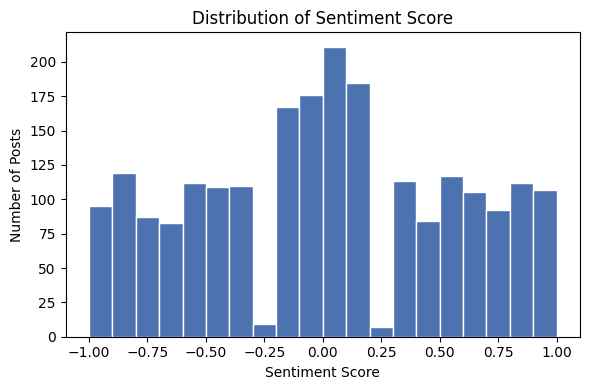

In [7]:
# TODO 6: Histogram of sentiment_score
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(df["sentiment_score"], bins=20, color="#4C72B0", edgecolor="white")
ax.set_title("Distribution of Sentiment Score")
ax.set_xlabel("Sentiment Score")
ax.set_ylabel("Number of Posts")
plt.tight_layout()
plt.show()


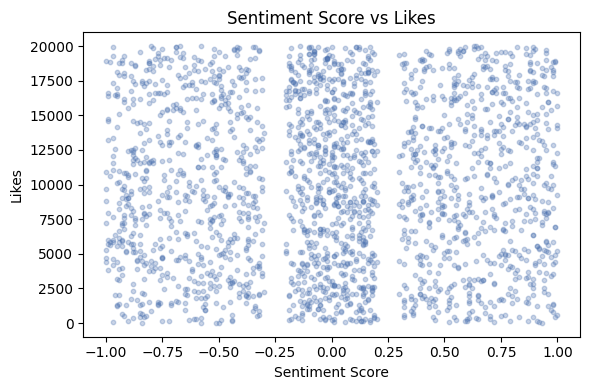

In [8]:
# TODO 7: Scatter plot of sentiment_score (x) vs likes (y)
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(df["sentiment_score"], df["likes"], alpha=0.3, s=10, color="#4C72B0")
ax.set_xlabel("Sentiment Score")
ax.set_ylabel("Likes")
ax.set_title("Sentiment Score vs Likes")
plt.tight_layout()
plt.show()


## Reflection

Answer briefly in this markdown cell:

1. What pattern did you find between sentiment and engagement (likes)?
2. Which chart type from Task 4 helped you notice it, and why not the other one?
3. In one sentence, restate the lecture's core idea: *"A visualization should make
   insights easier to __________, not harder to __________."*

**Your answers:**

1. From the results, I found that there is almost **no relationship** between `sentiment_score` and `likes`, since the correlation is only around 0.015. This means a post can get a similar number of likes whether its sentiment is positive, neutral, or negative.
2. The **scatter plot** helped me notice this because I could directly compare sentiment and likes and see that there was no clear upward or downward pattern. The histogram only showed how the sentiment scores were distributed, so it could not show their relationship with likes.
3. A visualization should make insights easier to **understand**, not harder to **interpret**.
